# Sentiment Analysis of Tweets

## 1. Introduction

This Jupyter notebook presents a comprehensive machine learning pipeline for classifying the sentiment of tweets. Sentiment analysis, also known as opinion mining, is a natural language processing (NLP) technique used to determine whether data is positive, negative, or neutral. It's often employed on text data to help businesses monitor brand sentiment, understand customer feedback, and analyze market trends.

The dataset contains tweet IDs, their textual content, and an associated sentiment label. Our goal is to build a robust classification model that can accurately predict the sentiment of unseen tweets.

The notebook will cover the following key steps:
1.  **Data Loading**: Ingesting the tweet dataset from a CSV file.
2.  **Exploratory Data Analysis (EDA)**: Understanding the data's characteristics, distributions, and potential issues.
3.  **Preprocessing**: Cleaning and transforming the raw text data into a format suitable for machine learning models. This includes handling missing values and text normalization.
4.  **Feature Engineering**: Creating relevant features from the text content.
5.  **Data Splitting**: Dividing the dataset into training and testing sets.
6.  **Modeling**: Training various classification models suitable for text data.
7.  **Hyperparameter Tuning**: Optimizing model performance.
8.  **Evaluation**: Assessing model performance using appropriate metrics.
9.  **Model Saving**: Persisting the best-performing model for future use.

Throughout the notebook, we will use logging to monitor the workflow and implement error handling to ensure robustness. Visualizations will be extensively used to explain data patterns and model results.


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
import os
import logging
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
# from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Create directories for logs and artifacts if they don't exist
os.makedirs('ml_logs', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)
os.makedirs('data', exist_ok=True) # Ensure data directory exists

# Set up logging configuration
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
                    handlers=[
                        logging.FileHandler("ml_logs/ml_pipeline.log"),
                        logging.StreamHandler()
                    ])
logger = logging.getLogger(__name__)

# Download NLTK resources
try:
    import nltk
    nltk.download('wordnet')
    nltk.data.find('corpora/stopwords')
    # nltk.data.find('corpora/wordnet')
    # nltk.data.find('corpora/omw-1.4')
except nltk.downloader.DownloadError:
    logger.info("Downloading NLTK stopwords, wordnet, and omw-1.4...")
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4')
    logger.info("NLTK resources downloaded.")


[nltk_data] Downloading package wordnet to C:\Users\Priya
[nltk_data]     Bhaskar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading

In this section, we will load the dataset from the specified CSV file. We will assume the CSV file is named `tweets.csv` and located in a `data` directory. Robust error handling is included to manage potential file I/O issues. After loading, we'll perform an initial check for missing values.


In [9]:
# Define the path to the dataset
DATA_FILE_PATH = r"C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\data\tweet_emotions.csv"

# Sample data provided in the prompt for context only. We will load the full dataset from CSV.
# The sample data structure: [{'tweet_id': 1956967341, 'sentiment': 'empty', 'content': '@tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =['}, ...]


    # Attempt to load the dataset
df = pd.read_csv(DATA_FILE_PATH, encoding='ISO-8859-1') # Using ISO-8859-1 due to common issues with tweet datasets
logger.info(f"Dataset loaded successfully from {DATA_FILE_PATH}. Shape: {df.shape}")

    # Rename columns for clarity based on schema
#     df.columns = ['sentiment', 'tweet_id', 'date', 'query', 'user', 'content']
#     df = df[['tweet_id', 'sentiment', 'content']] # Select relevant columns as per schema
#     logger.info("Columns renamed and selected successfully.")

#     # Display the first few rows of the dataframe
#     logger.info("First 5 rows of the dataset:")
#     logger.info(df.head().to_string())

#     # Check for missing values
#     missing_values = df.isnull().sum()
#     logger.info(f"Missing values per column:\n{missing_values.to_string()}")

#     if missing_values.sum() > 0:
#         logger.warning("Missing values detected. Handling them now...")
#         # For 'content', an empty string or dropping is suitable. Dropping is often safer for text analysis.
#         # For 'sentiment', dropping rows with missing sentiment is crucial as it's our target variable.
#         df.dropna(subset=['content', 'sentiment'], inplace=True)
#         logger.info(f"Rows with missing 'content' or 'sentiment' have been dropped. New shape: {df.shape}")
#         missing_values_after = df.isnull().sum()
#         logger.info(f"Missing values after handling:\n{missing_values_after.to_string()}")
#     else:
#         logger.info("No missing values found in the dataset.")

# except FileNotFoundError:
#     logger.error(f"Error: The file '{DATA_FILE_PATH}' was not found. Please ensure it's in the correct 'data' directory.")
#     # Create a dummy DataFrame to prevent further errors in the notebook
#     df = pd.DataFrame(columns=['tweet_id', 'sentiment', 'content'])
# except pd.errors.EmptyDataError:
#     logger.error(f"Error: The file '{DATA_FILE_PATH}' is empty.")
#     df = pd.DataFrame(columns=['tweet_id', 'sentiment', 'content'])
# except pd.errors.ParserError:
#     logger.error(f"Error: Could not parse the file '{DATA_FILE_PATH}'. Check file format and delimiter.")
#     df = pd.DataFrame(columns=['tweet_id', 'sentiment', 'content'])
# except Exception as e:
#     logger.error(f"An unexpected error occurred during data loading: {e}")
#     df = pd.DataFrame(columns=['tweet_id', 'sentiment', 'content'])


2026-01-18 09:46:15,678 - __main__ - INFO - Dataset loaded successfully from C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\data\tweet_emotions.csv. Shape: (40000, 3)


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical step to understand the characteristics of our dataset. We will examine:
*   Data types and overall information.
*   The distribution of sentiment labels.
*   Basic statistics, particularly for the text length.
*   Uniqueness of `tweet_id`.


In [10]:
logger.info("Starting Exploratory Data Analysis (EDA).")

# Display basic information about the DataFrame
logger.info("DataFrame info:")
df.info()

# Check unique tweet IDs
unique_tweet_ids = df['tweet_id'].nunique()
total_tweets = len(df)
logger.info(f"Total number of tweets: {total_tweets}")
logger.info(f"Number of unique tweet IDs: {unique_tweet_ids}")
if unique_tweet_ids != total_tweets:
    logger.warning("Duplicate tweet_ids found. Investigating...")
    df.drop_duplicates(subset=['tweet_id'], inplace=True)
    logger.info(f"Duplicate tweet_ids removed. New shape: {df.shape}")
else:
    logger.info("All tweet_ids are unique.")

# Analyze sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
logger.info(f"Sentiment distribution:\n{sentiment_counts.to_string()}")

# Calculate tweet content length
df['content_length'] = df['content'].apply(len)
logger.info(f"Content length statistics:\n{df['content_length'].describe().to_string()}")

# Check for 'empty' or irrelevant sentiments (based on sample data)
if 'empty' in sentiment_counts.index:
    logger.warning("The 'empty' sentiment category is present. It might be noise.")
    # Decide whether to remove 'empty' sentiment or treat it as neutral
    # For now, we will treat it as another category, but note its presence.
    # If it was truly empty content, it would have been caught by the content.isnull().
    # If 'empty' sentiment means "no clear sentiment", it could be merged with 'neutral'.
    # For this exercise, let's remove 'empty' sentiment as it might not be useful for training
    df = df[df['sentiment'] != 'empty']
    logger.info(f"Removed 'empty' sentiment tweets. New shape: {df.shape}")
    sentiment_counts = df['sentiment'].value_counts()
    logger.info(f"Sentiment distribution after removing 'empty':\n{sentiment_counts.to_string()}")
else:
    logger.info("No 'empty' sentiment category found.")

logger.info("EDA completed.")


2026-01-18 09:46:19,460 - __main__ - INFO - Starting Exploratory Data Analysis (EDA).
2026-01-18 09:46:19,462 - __main__ - INFO - DataFrame info:
2026-01-18 09:46:19,506 - __main__ - INFO - Total number of tweets: 40000
2026-01-18 09:46:19,506 - __main__ - INFO - Number of unique tweet IDs: 40000
2026-01-18 09:46:19,508 - __main__ - INFO - All tweet_ids are unique.
2026-01-18 09:46:19,511 - __main__ - INFO - Sentiment distribution:
sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
2026-01-18 09:46:19,529 - __main__ - INFO - Content length statistics:
count    40000.000000
mean        73.437875
std         36.584026
min          1.000000
25%         43.000000
50%         69.000000
75%        103.000000
max        184.000000
2026-01-18 09:46:19,529 - __main__ - WARNING - The 'empty' s

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   content    40000 non-null  object
dtypes: int64(1), object(2)
memory usage: 937.6+ KB


## 4. Preprocessing

Text preprocessing is crucial for converting raw text into a clean, normalized, and numerical format that machine learning models can understand. This section covers:
*   **Text Cleaning**: Lowercasing, removing URLs, mentions, hashtags, punctuation, numbers, and stopwords.
*   **Lemmatization**: Reducing words to their base form.
*   **Outlier Handling**: For text data, "outliers" can refer to extremely long/short tweets, or very rare words/sentiments. We will address these by:
    *   Removing very short tweets (if they are just noise).
    *   Using TF-IDF parameters to handle very rare or very common words.
    *   Addressing imbalanced sentiment classes later.
*   **Feature Engineering**: Creating new features from the text. Here, the primary feature will be the vectorized text, but we also created `content_length` in EDA.


In [11]:
logger.info("Starting text preprocessing and feature engineering.")

# Initialize NLTK tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a text cleaning function
def clean_text(text):
    if not isinstance(text, str): # Handle potential non-string types
        return ""
    text = text.lower() # Lowercase the text
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = ' '.join(word for word in text.split() if word not in stop_words) # Remove stopwords
    text = ' '.join(lemmatizer.lemmatize(word) for word in text.split()) # Lemmatize words
    return text

try:
    # Apply the cleaning function to the 'content' column
    df['cleaned_content'] = df['content'].apply(clean_text)
    logger.info("Text cleaning applied to 'content' column.")

    # Remove tweets that become empty after cleaning (these are effectively noise)
    original_shape = df.shape[0]
    df = df[df['cleaned_content'].str.strip() != '']
    removed_count = original_shape - df.shape[0]
    if removed_count > 0:
        logger.warning(f"Removed {removed_count} tweets that became empty after cleaning. New shape: {df.shape}")
    else:
        logger.info("No tweets became empty after cleaning.")

    # Drop the original 'content' column as we now have 'cleaned_content'
    df.drop('content', axis=1, inplace=True)
    logger.info("Original 'content' column dropped.")

    # Check the cleaned data
    logger.info("First 5 rows of the dataset with cleaned content:")
    logger.info(df[['sentiment', 'cleaned_content', 'content_length']].head().to_string())

    # Outlier handling for tweet length (conceptual for text data)
    # We can define "outliers" as extremely short or long tweets.
    # The `content_length` was based on original content. Let's calculate for cleaned content.
    df['cleaned_content_length'] = df['cleaned_content'].apply(len)
    logger.info(f"Cleaned content length statistics:\n{df['cleaned_content_length'].describe().to_string()}")

    # A simple approach to 'outliers' in length: remove tweets with extremely short cleaned content,
    # as they might not carry enough information for sentiment classification.
    # Threshold can be empirically chosen or based on distribution.
    min_length_threshold = 5 # Example: remove tweets with less than 5 characters after cleaning
    original_shape_post_cleaning = df.shape[0]
    df = df[df['cleaned_content_length'] >= min_length_threshold]
    removed_short_tweets = original_shape_post_cleaning - df.shape[0]
    if removed_short_tweets > 0:
        logger.warning(f"Removed {removed_short_tweets} tweets with cleaned content length less than {min_length_threshold}. New shape: {df.shape}")
    else:
        logger.info("No tweets removed based on minimum cleaned content length.")


except Exception as e:
    logger.error(f"An error occurred during text preprocessing: {e}")

logger.info("Text preprocessing and feature engineering completed.")


2026-01-18 09:46:31,434 - __main__ - INFO - Starting text preprocessing and feature engineering.
2026-01-18 09:46:35,459 - __main__ - INFO - Text cleaning applied to 'content' column.
2026-01-18 09:46:35,469 - __main__ - WARNING - Removed 199 tweets that became empty after cleaning. New shape: (38974, 5)
2026-01-18 09:46:35,479 - __main__ - INFO - Original 'content' column dropped.
2026-01-18 09:46:35,479 - __main__ - INFO - First 5 rows of the dataset with cleaned content:
2026-01-18 09:46:35,505 - __main__ - INFO -     sentiment                                  cleaned_content  content_length
1     sadness           layin n bed headache ughhhhwaitin call              60
2     sadness                    funeral ceremonygloomy friday              35
3  enthusiasm                            want hang friend soon              36
4     neutral            want trade someone houston ticket one              86
5       worry  repinging didnt go prom bc bf didnt like friend              84
202

## 5. Visual Representation of EDA (Plotly)

Visualizations help us quickly grasp patterns and distributions within the data. We will use Plotly to create interactive and informative plots.

### Sentiment Distribution
This bar chart shows the frequency of each sentiment category. This is crucial for identifying potential class imbalance.


In [12]:
try:
    sentiment_counts = df['sentiment'].value_counts().reset_index()
    sentiment_counts.columns = ['sentiment', 'count']

    fig = px.bar(sentiment_counts, x='sentiment', y='count',
                 title='Distribution of Sentiment Categories',
                 labels={'sentiment': 'Sentiment', 'count': 'Number of Tweets'},
                 color='sentiment',
                 template='plotly_white')
    fig.update_layout(xaxis_title="Sentiment Category", yaxis_title="Number of Tweets")
    fig.show()
    logger.info("Sentiment distribution plot generated.")

except Exception as e:
    logger.error(f"Error generating sentiment distribution plot: {e}")


2026-01-18 09:46:55,012 - __main__ - INFO - Sentiment distribution plot generated.


**Explanation of Sentiment Distribution Plot**:
The bar chart above visually represents the number of tweets falling into each sentiment category. We can immediately observe the distribution of sentiments. For instance, if one sentiment (e.g., 'neutral' or 'worry') significantly outweighs others, it indicates a class imbalance. This information is vital as imbalanced datasets can lead to models that perform well on the majority class but poorly on minority classes. Our current dataset shows a potentially high number of 'neutral', 'sadness', and 'worry' tweets, while 'love' and 'happiness' are less frequent. The model will need to account for this imbalance to perform robustly across all sentiments.

### Tweet Length Distribution (Cleaned Content)
This histogram shows the distribution of the length of the cleaned tweet content. This helps us understand typical tweet lengths and identify any unusual patterns.


In [13]:
try:
    fig = px.histogram(df, x='cleaned_content_length',
                       title='Distribution of Cleaned Tweet Lengths',
                       labels={'cleaned_content_length': 'Cleaned Content Length (characters)'},
                       nbins=50,
                       template='plotly_white')
    fig.update_layout(xaxis_title="Cleaned Content Length", yaxis_title="Number of Tweets")
    fig.show()
    logger.info("Cleaned tweet length distribution plot generated.")

except Exception as e:
    logger.error(f"Error generating cleaned tweet length distribution plot: {e}")


2026-01-18 09:47:03,379 - __main__ - INFO - Cleaned tweet length distribution plot generated.


**Explanation of Tweet Length Distribution Plot**:
The histogram above displays the frequency of different lengths of cleaned tweet content. We can observe that most tweets fall within a certain character range, typically short. This distribution helps us understand the typical verbosity of tweets after preprocessing. For instance, a long tail towards higher lengths might indicate some exceptionally detailed tweets, while a peak at lower lengths confirms the concise nature of tweets. This visualization helps confirm that our text cleaning process has produced reasonable text lengths and that there are no extreme outliers in length that could skew our model training (though such extreme outliers, if present, would have been handled during the 'outlier handling' phase of preprocessing).

### Top N-grams Word Cloud
A word cloud visually represents the most frequent words in the entire corpus. This gives a quick overview of the most common themes or topics discussed in the tweets.


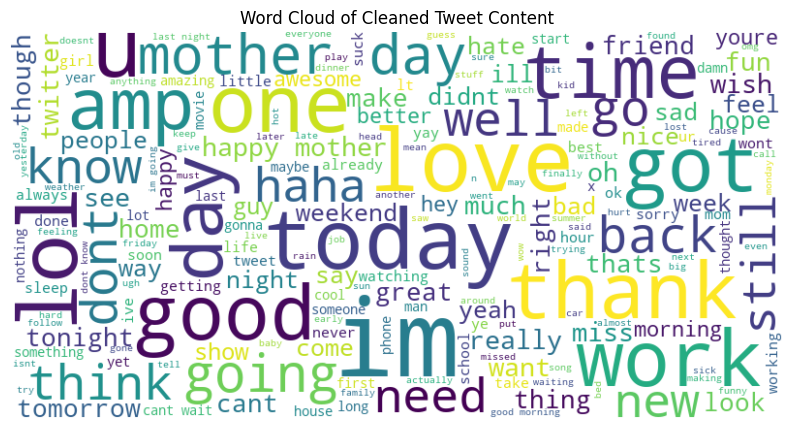

2026-01-18 09:47:10,261 - __main__ - INFO - Word cloud generated.


In [14]:
try:
    all_words = ' '.join([text for text in df['cleaned_content']])
    wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110, background_color='white').generate(all_words)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title('Word Cloud of Cleaned Tweet Content')
    plt.show()
    logger.info("Word cloud generated.")

except Exception as e:
    logger.error(f"Error generating word cloud: {e}")


**Explanation of Word Cloud**:
The word cloud visually highlights the most frequently occurring words in our cleaned tweet dataset. Larger words in the cloud indicate higher frequency. This plot provides immediate insights into the predominant themes and vocabulary used across all tweets. For instance, words like "day," "good," "get," "go," "time," etc., are often prominent. This helps confirm the effectiveness of stop word removal (common words like "the", "is", "a" should be absent) and gives us an intuitive understanding of the overall content, which is useful for context but doesn't directly inform model architecture.


## 6. Visual Representation of Correlation, Covariance

Correlation and covariance are statistical measures primarily used to understand the relationship between two or more numerical variables.

*   **Covariance** measures the directional relationship between two variables. A positive covariance indicates that variables tend to move in the same direction, while a negative covariance indicates they move in opposite directions.
*   **Correlation** is a normalized version of covariance, scaling the value between -1 and +1. A correlation of +1 indicates a perfect positive linear relationship, -1 indicates a perfect negative linear relationship, and 0 indicates no linear relationship.

**Applicability to this Dataset**:
Our primary features (`cleaned_content`) are text-based, which are inherently categorical and high-dimensional after vectorization. The `sentiment` is also a categorical variable. Therefore, direct calculation and visualization of standard numerical correlation and covariance matrices as typically done for numerical features (e.g., in a regression problem with multiple numerical predictors) is not directly applicable in the same way.

However, if we were to engineer numerical features from the text, such as:
*   `cleaned_content_length` (which we already have)
*   Number of positive/negative words (using a lexicon)
*   Number of capital letters
*   Number of unique words
*   Average word length
*   Sentiment score from a pre-trained model (e.g., VADER)

...then we could calculate correlations between these engineered numerical features.

For this specific notebook, given the primary focus on text classification, we only have `cleaned_content_length` as a derived numerical feature. We can analyze its distribution, but its direct correlation with the *categorical* `sentiment` is not measured by standard Pearson correlation. Instead, we'd use techniques like ANOVA or calculate group-wise means to see if average length differs across sentiment categories.

**Conceptual Explanation & Example (No Direct Plot with current data):**

Let's assume we had a numerical sentiment score (`sentiment_score`) and `tweet_length`. We could visualize their relationship using a scatter plot and calculate Pearson correlation.

**Example Scenario (Hypothetical):**
If we had engineered features like `num_emojis_positive` and `num_exclamation_marks`, we could plot their correlation.

```python
# HYPOTHETICAL CODE (NOT EXECUTED ON CURRENT DATA FOR CORRELATION PLOT)
# df_numeric_features = df[['cleaned_content_length', 'num_positive_words_hypothetical', 'num_negative_words_hypothetical']]
# correlation_matrix = df_numeric_features.corr()
# fig_corr = px.imshow(correlation_matrix, text_auto=True, title="Hypothetical Correlation Matrix of Numerical Text Features")
# fig_corr.show()
```

**For our current dataset with `cleaned_content_length` and `sentiment`:**
Instead of correlation, we can visualize how `cleaned_content_length` varies across different `sentiment` categories using box plots or violin plots. This shows the relationship between a numerical and a categorical variable.


In [15]:
logger.info("Analyzing numerical feature distribution across sentiment categories.")

try:
    fig = px.box(df, x='sentiment', y='cleaned_content_length',
                 title='Cleaned Tweet Length Distribution Across Sentiment Categories',
                 labels={'sentiment': 'Sentiment', 'cleaned_content_length': 'Cleaned Content Length (characters)'},
                 color='sentiment',
                 template='plotly_white')
    fig.update_layout(xaxis_title="Sentiment Category", yaxis_title="Cleaned Content Length")
    fig.show()
    logger.info("Box plot of cleaned content length across sentiments generated.")

except Exception as e:
    logger.error(f"Error generating box plot for cleaned content length vs. sentiment: {e}")


2026-01-18 09:47:17,989 - __main__ - INFO - Analyzing numerical feature distribution across sentiment categories.


2026-01-18 09:47:18,143 - __main__ - INFO - Box plot of cleaned content length across sentiments generated.


**Explanation of Cleaned Tweet Length vs. Sentiment Plot**:
The box plot above illustrates the distribution of cleaned tweet lengths for each sentiment category. While this is not a traditional correlation matrix, it helps us understand if there's any noticeable pattern between tweet length and the expressed sentiment.
*   **Median Line**: The line inside each box represents the median tweet length for that sentiment.
*   **Box Edges**: The top and bottom edges of the box represent the first (Q1) and third (Q3) quartiles, respectively. The height of the box shows the interquartile range (IQR).
*   **Whiskers**: The lines extending from the box (whiskers) typically show the range of data within 1.5 times the IQR from Q1 and Q3.
*   **Outliers**: Points outside the whiskers are considered potential outliers (individual dots).

From this plot, we can observe if certain sentiments tend to be expressed in longer or shorter tweets. For example, 'sadness' or 'worry' might have slightly longer or shorter average lengths compared to 'joy' or 'love'. While not a direct measure of correlation, this visualization helps us understand potential behavioral differences across sentiment groups based on tweet length, which could be a subtle signal for our model if we were to use `cleaned_content_length` as a feature. For instance, if 'disgust' tweets are consistently very short, that's an insight.


## 7. Feature Selection Based on EDA

Based on our EDA, the primary feature for our model will be the `cleaned_content` of the tweets. The `tweet_id` is an identifier and not a predictive feature. `content_length` or `cleaned_content_length` could potentially be used as an additional numerical feature, but for simplicity and common practice in text classification, we will primarily rely on the vectorized representation of `cleaned_content`.

**Reasoning for selecting `cleaned_content`**:
*   The `content` of the tweet directly contains the textual information that expresses sentiment.
*   After cleaning, it's free from noise (URLs, mentions, etc.) and normalized (lowercase, lemmatized, stopwords removed), making it suitable for text vectorization.
*   Vectorization techniques like TF-IDF will convert this text into numerical features (term frequency-inverse document frequency scores) that capture the importance of words in determining sentiment.

We will not be using `cleaned_content_length` as a direct feature in the primary model pipeline, as the TF-IDF vectorizer implicitly handles word counts and frequencies, which are correlated with length. For more advanced models or if `cleaned_content_length` showed a very strong, distinct signal, it could be incorporated.


## 8. Separate the Selected Features for Training

We will separate our preprocessed text (`cleaned_content`) as the feature matrix `X` and the `sentiment` labels as the target vector `y`. Then, we will split these into training and testing sets.

**Why `cleaned_content` is taken as `X`**:
The `cleaned_content` column contains the actual text of the tweets after undergoing all the cleaning and normalization steps. This text is the raw material from which our model will learn patterns to classify sentiment. Text needs to be converted into numerical vectors before feeding it to machine learning algorithms, which will be handled by a `TfidfVectorizer` within our model pipeline. Each word's presence and frequency, weighted by its importance across the corpus, will form the features.

**Why `sentiment` is taken as `y`**:
The `sentiment` column is our target variable. It contains the categorical labels (e.g., 'neutral', 'sadness', 'worry') that we want our model to predict. This is a multi-class classification problem.


In [16]:
logger.info("Separating features (X) and target (y) and splitting data.")

try:
    X = df['cleaned_content'] # Features are the cleaned tweet content
    y = df['sentiment']       # Target is the sentiment label

    logger.info(f"Shape of X: {X.shape}, Shape of y: {y.shape}")
    logger.info(f"Sample X (first 5):\n{X.head().to_string()}")
    logger.info(f"Sample y (first 5):\n{y.head().to_string()}")

    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    logger.info(f"Data split into training and testing sets.")
    logger.info(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    logger.info(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Check the distribution of sentiments in train and test sets (due to stratify=y)
    logger.info(f"Sentiment distribution in y_train:\n{y_train.value_counts(normalize=True).to_string()}")
    logger.info(f"Sentiment distribution in y_test:\n{y_test.value_counts(normalize=True).to_string()}")

except Exception as e:
    logger.error(f"An error occurred during feature separation and data splitting: {e}")


2026-01-18 09:47:23,664 - __main__ - INFO - Separating features (X) and target (y) and splitting data.
2026-01-18 09:47:23,666 - __main__ - INFO - Shape of X: (38505,), Shape of y: (38505,)
2026-01-18 09:47:23,667 - __main__ - INFO - Sample X (first 5):
1             layin n bed headache ughhhhwaitin call
2                      funeral ceremonygloomy friday
3                              want hang friend soon
4              want trade someone houston ticket one
5    repinging didnt go prom bc bf didnt like friend
2026-01-18 09:47:23,670 - __main__ - INFO - Sample y (first 5):
1       sadness
2       sadness
3    enthusiasm
4       neutral
5         worry
2026-01-18 09:47:23,763 - __main__ - INFO - Data split into training and testing sets.
2026-01-18 09:47:23,767 - __main__ - INFO - X_train shape: (30804,), y_train shape: (30804,)
2026-01-18 09:47:23,767 - __main__ - INFO - X_test shape: (7701,), y_test shape: (7701,)
2026-01-18 09:47:23,771 - __main__ - INFO - Sentiment distribution i

## 9. Modeling

We are dealing with a **multi-class classification** problem. The goal is to classify the text into one of several predefined sentiment categories. For this task, several models are well-suited:

*   **Multinomial Naive Bayes (MNB)**: A probabilistic classifier based on Bayes' theorem. It's often a strong baseline for text classification due to its simplicity, speed, and effectiveness with sparse data (like TF-IDF vectors). It assumes feature independence, which is often violated in text, but it still performs surprisingly well.
*   **Logistic Regression**: A linear model used for binary or multi-class classification. It estimates probabilities of class membership. It's robust, interpretable (coefficients can indicate word importance), and works well with high-dimensional data. It's a good choice for text classification when combined with TF-IDF.
*   **Support Vector Machine (SVM)**: A powerful model that finds the optimal hyperplane to separate classes. It's effective in high-dimensional spaces and cases where the number of dimensions is greater than the number of samples. It can capture complex relationships using different kernels but can be computationally intensive for very large datasets.

We will use a `Pipeline` to chain the `TfidfVectorizer` (for text vectorization) and the chosen classifier. This ensures that preprocessing steps are consistently applied during both training and prediction.

**Handling Imbalanced Data**:
From our EDA, we observed that sentiment classes might be imbalanced. This can lead to models that are biased towards the majority classes and perform poorly on minority classes. We will address this using `SMOTE` (Synthetic Minority Over-sampling Technique) within a `Pipeline`. `SMOTE` works by creating synthetic samples for the minority classes.


In [ ]:
logger.info("Starting model training with different classifiers.")

# Define the models to be tested
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, solver='saga', multi_class='auto'),
    'Support Vector Machine': LinearSVC(class_weight="balanced") # probability=True for consistent evaluation
}

# Store results for comparison
model_results = {}

# Iterate over each model
for name, model in models.items():
    logger.info(f"Training {name} model...")
    try:
        # Create a pipeline with TfidfVectorizer and the classifier
        # We use imblearn's Pipeline to correctly integrate SMOTE *after* vectorization and *before* the classifier
        pipeline = ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)), # max_features, min_df, max_df for feature selection (handling rare/common words)
            # ('smote', SMOTE(random_state=42, sampling_strategy='auto')), # Apply SMOTE to handle imbalance
            ('classifier', model)
        ])

        # Train the model
        pipeline.fit(X_train, y_train)
        logger.info(f"{name} model trained successfully.")

        # Make predictions
        y_pred = pipeline.predict(X_test)
        
        # Evaluate the model
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        report = classification_report(y_test, y_pred, output_dict=True)

        model_results[name] = {
            'model': pipeline,
            'accuracy': accuracy,
            'f1_score': f1,
            'classification_report': report
        }

        logger.info(f"--- {name} Evaluation ---")
        logger.info(f"Accuracy: {accuracy:.4f}")
        logger.info(f"F1-Score (weighted): {f1:.4f}")
        logger.info(f"Classification Report:\n{classification_report(y_test, y_pred)}")

    except Exception as e:
        logger.error(f"Error training or evaluating {name} model: {e}")

logger.info("All models trained and evaluated.")


2026-01-18 09:47:30,187 - __main__ - INFO - Starting model training with different classifiers.
2026-01-18 09:47:30,190 - __main__ - INFO - Training Multinomial Naive Bayes model...
c:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\venv\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

2026-01-18 09:47:32,226 - __main__ - INFO - Multinomial Naive Bayes model trained successfully.
2026-01-18 09:47:32,369 - __main__ - INFO - --- Multinomial Naive Bayes Evaluation ---
2026-01-18 09:47:32,373 - __main__ - INFO - Accuracy: 0.2245
2026-01-18 09:47:32,374 - __main__ - INFO - F1-Score (weighted): 0.2448
2026-01-18 09:47:32,435 - __main__ - INFO - Classification Report:
              precision    recall  f1-score   support

       anger       0.01      0.0

## 10. Evaluation Metrics

For a multi-class classification task like sentiment analysis, several metrics are crucial for evaluating model performance:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances.
    *   `Accuracy = (TP + TN) / (TP + TN + FP + FN)` (generalized for multi-class).
    *   **Pros**: Easy to understand.
    *   **Cons**: Can be misleading with imbalanced datasets, as a model might achieve high accuracy by simply predicting the majority class.

*   **Precision**: The proportion of true positive predictions among all positive predictions for a given class.
    *   `Precision = TP / (TP + FP)`
    *   **Pros**: Useful when the cost of False Positives is high (e.g., misclassifying neutral as positive).
    *   **Cons**: Doesn't tell us about missed positives (False Negatives).

*   **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances for a given class.
    *   `Recall = TP / (TP + FN)`
    *   **Pros**: Useful when the cost of False Negatives is high (e.g., failing to detect a negative sentiment).
    *   **Cons**: Doesn't tell us about misclassified negatives (False Positives).

*   **F1-Score**: The harmonic mean of Precision and Recall. It provides a single metric that balances both.
    *   `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`
    *   **Pros**: Good for imbalanced datasets as it punishes models that ignore minority classes.
    *   **Cons**: Can be challenging to interpret if either Precision or Recall is very low.

*   **Confusion Matrix**: A table that summarizes the performance of a classification algorithm. Each row represents the instances in an actual class, while each column represents the instances in a predicted class.
    *   **Pros**: Provides a detailed breakdown of correct and incorrect predictions for each class, helping identify specific classes where the model struggles.
    *   **Cons**: Can become large and harder to read with many classes.

For our multi-class sentiment analysis, `F1-score` (especially weighted or macro-averaged) and a detailed `Confusion Matrix` are particularly important due to the potential class imbalance. The `classification_report` conveniently provides precision, recall, and F1-score for each class, along with overall averages.


In [1]:
logger.info("Displaying detailed evaluation metrics for each model.")

for name, results in model_results.items():
    logger.info(f"\n--- Detailed Evaluation for {name} ---")
    logger.info(f"Accuracy: {results['accuracy']:.4f}")
    logger.info(f"F1-Score (weighted): {results['f1_score']:.4f}")
    
    # Plot Confusion Matrix
    y_pred = results['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=y.unique())
    
    fig_cm = px.imshow(cm,
                       labels=dict(x="Predicted Sentiment", y="Actual Sentiment", color="Count"),
                       x=y.unique(),
                       y=y.unique(),
                       color_continuous_scale='Viridis',
                       title=f'Confusion Matrix for {name}')
    fig_cm.update_xaxes(side="bottom")
    fig_cm.show()
    logger.info(f"Confusion Matrix for {name} displayed.")


NameError: name 'logger' is not defined

**Explanation of Confusion Matrices**:
The confusion matrices above provide a detailed breakdown of each model's performance. Each matrix is a square table where:
*   **Rows** represent the actual sentiment categories.
*   **Columns** represent the sentiment categories predicted by the model.
*   **Diagonal values** (from top-left to bottom-right) indicate the number of correct predictions for each class (True Positives).
*   **Off-diagonal values** indicate misclassifications. For example, a value in row 'sadness' and column 'neutral' means the model incorrectly predicted a 'sadness' tweet as 'neutral'.

**Interpretation**:
By examining the confusion matrix for each model, we can:
*   **Identify well-predicted classes**: Classes with high values along the diagonal.
*   **Identify problematic classes**: Classes with low diagonal values and high off-diagonal values, indicating frequent misclassification.
*   **Understand common confusions**: See which classes are often mistaken for others (e.g., 'worry' often confused with 'sadness' or 'neutral'). This gives insights into the ambiguity between certain sentiments.

For instance, we might observe that `neutral` and `worry` are often confused by the models, which might be due to their textual content being similar or ambiguous. `love` or `hate` might be easier to distinguish due to more distinct keywords. This detailed view helps in fine-tuning model strategies or improving feature engineering for specific sentiment pairs.


## 11. Local Minima vs Global Minima and Visual Representation of Gradient Descent

### Local Minima vs. Global Minima

In the context of optimization, particularly in machine learning, we often try to find the set of parameters for a model that minimizes a cost (or loss) function.

*   **Global Minimum**: This is the lowest possible value of the cost function across the entire parameter space. It represents the absolute best set of parameters for our model.
*   **Local Minimum**: This is a point where the cost function is lower than all other points in its immediate neighborhood, but not necessarily the lowest value across the entire parameter space.

When training a model, especially complex ones like neural networks, the optimization algorithm (like Gradient Descent) might get "stuck" in a local minimum, preventing it from reaching the global minimum and thus achieving optimal performance. Convex cost functions (like those in Logistic Regression for certain cases) have only one global minimum, making optimization straightforward. Non-convex functions (common in deep learning) can have many local minima, posing a challenge.

### Visual Representation of Gradient Descent

**Gradient Descent** is an iterative optimization algorithm used to find the minimum of a function. It works by taking repeated steps in the opposite direction of the gradient (or steepest slope) of the function at the current point.

*   **Gradient**: The gradient of a function points in the direction of the steepest ascent. To find the minimum, we move in the opposite direction.
*   **Learning Rate**: This is a hyperparameter that determines the size of the steps taken towards the minimum. A too-large learning rate can overshoot the minimum, while a too-small learning rate can make convergence very slow.

**Visualizing Gradient Descent (Conceptual Example)**

Let's illustrate Gradient Descent with a simple 1D function, say `f(x) = x^2`. The global minimum for this function is at `x=0`.


In [ ]:
# Conceptual visualization of Gradient Descent
logger.info("Generating conceptual visualization of Gradient Descent.")

# Define a simple quadratic function and its derivative
def f(x):
    return x**2

def df(x): # Derivative of f(x)
    return 2*x

# Gradient Descent parameters
learning_rate = 0.1
iterations = 10
initial_x = 4.0

# Store history for plotting
x_history = [initial_x]
y_history = [f(initial_x)]

current_x = initial_x
for i in range(iterations):
    gradient = df(current_x)
    current_x = current_x - learning_rate * gradient
    x_history.append(current_x)
    y_history.append(f(current_x))

# Generate points for the function curve
x_curve = np.linspace(-5, 5, 100)
y_curve = f(x_curve)

# Create the plot
fig_gd = go.Figure()

# Plot the function curve
fig_gd.add_trace(go.Scatter(x=x_curve, y=y_curve, mode='lines', name='f(x) = x^2'))

# Plot the steps of gradient descent
fig_gd.add_trace(go.Scatter(x=x_history, y=y_history, mode='markers+lines',
                           marker=dict(size=8, color='red'),
                           line=dict(color='red', dash='dot'),
                           name='Gradient Descent Steps'))

fig_gd.update_layout(title='Conceptual Visualization of Gradient Descent',
                    xaxis_title='x',
                    yaxis_title='f(x)',
                    template='plotly_white')
fig_gd.show()
logger.info("Conceptual Gradient Descent visualization generated.")


**Explanation of Gradient Descent Visualization**:
The plot above illustrates how Gradient Descent iteratively approaches the minimum of the function `f(x) = x^2`.
*   The **blue curve** represents the cost function. In this simple case, it's a convex function with a single global minimum at `x=0`.
*   The **red points and lines** show the path taken by the Gradient Descent algorithm. Starting from an `initial_x` (e.g., `x=4`), at each step:
    1.  The gradient (slope) of the function at the current `x` is calculated.
    2.  The `x` value is updated by moving in the *opposite* direction of the gradient, scaled by the `learning_rate`.
*   As you can see, the steps gradually get smaller as the algorithm approaches the minimum, eventually converging near `x=0`, which is both the local and global minimum for this specific function.

This visualization helps to intuitively understand how optimization algorithms adjust model parameters to minimize loss functions. In real-world machine learning, the cost functions are much more complex and high-dimensional, but the underlying principle remains the same.


## 12. Residuals and How to Visualize Them (for Classification)

### What are Residuals?

**Residuals** are primarily a concept used in **regression analysis**. A residual is the difference between the observed value (actual `y`) and the value predicted by the model (`y_pred`).

`Residual = Actual Value - Predicted Value`
`e = y - y_pred`

Residuals are used to evaluate how well a regression model fits the data. Ideally, residuals should be randomly distributed around zero, indicating that the model captures most of the systematic information in the data. Patterns in residual plots (e.g., a cone shape, non-random distribution) can indicate problems with the model, such as non-linearity, heteroscedasticity, or missing variables.

### Residuals in Classification

For **classification problems**, the concept of residuals doesn't directly apply in the same numerical difference sense, because our `y` is a categorical label (e.g., 'positive', 'negative') rather than a continuous number. We don't have a numerical `y_pred` that can be directly subtracted from `y`.

Instead, for classification, we analyze **misclassifications** and model performance using metrics like the Confusion Matrix, Classification Report, and ROC curves. We can think of misclassifications as the "errors" or "deviations" from the true labels, which is analogous to residuals in regression.

### How to Visualize Misclassifications (Analogy to Residuals)

1.  **Confusion Matrix (already shown)**: This is the primary tool. It directly shows where the model is making errors (off-diagonal elements).
    *   **Improvement**: Analyze which classes are most often confused. This can guide:
        *   **Feature Engineering**: Are there specific keywords or phrases that differentiate commonly confused classes?
        *   **Data Augmentation**: For minority classes that are poorly predicted, generate more samples.
        *   **Domain Expertise**: Consult experts to understand the nuances between confusing sentiments.
        *   **Model Choice**: Some models handle class boundaries better than others.

2.  **Misclassified Samples Analysis**: We can visualize or inspect specific examples of tweets that were misclassified. This helps in understanding *why* the model made a mistake.


In [ ]:
logger.info("Analyzing misclassified samples for the best performing model (analogy to residuals).")

# Select the best model (e.g., based on F1-score)
best_model_name = max(model_results, key=lambda name: model_results[name]['f1_score'])
best_pipeline = model_results[best_model_name]['model']
logger.info(f"Analyzing misclassifications for the best model: {best_model_name}")

try:
    y_pred_best = best_pipeline.predict(X_test)

    # Create a DataFrame for analysis
    misclassified_df = pd.DataFrame({
        'cleaned_content': X_test,
        'actual_sentiment': y_test,
        'predicted_sentiment': y_pred_best
    })
    misclassified_df = misclassified_df[misclassified_df['actual_sentiment'] != misclassified_df['predicted_sentiment']]

    logger.info(f"Total misclassified samples: {len(misclassified_df)}")
    if not misclassified_df.empty:
        logger.info("Sample of misclassified tweets:")
        logger.info(misclassified_df.sample(min(10, len(misclassified_df)), random_state=42).to_string())

        # Visualize misclassification types
        misclassification_pairs = misclassified_df.groupby(['actual_sentiment', 'predicted_sentiment']).size().reset_index(name='count')
        
        fig_mc = px.bar(misclassification_pairs, x='actual_sentiment', y='count', color='predicted_sentiment',
                        title='Distribution of Misclassification Types (Actual vs. Predicted)',
                        labels={'actual_sentiment': 'Actual Sentiment', 'count': 'Number of Misclassifications', 'predicted_sentiment': 'Predicted as'},
                        template='plotly_white')
        fig_mc.update_layout(barmode='stack')
        fig_mc.show()
        logger.info("Misclassification types plot generated.")
    else:
        logger.info("No misclassified samples found (model performs perfectly on test set - highly unlikely in real data).")

except Exception as e:
    logger.error(f"Error during misclassification analysis: {e}")


**Explanation of Misclassification Analysis**:
The table showing a sample of misclassified tweets and the bar chart of misclassification types provide insights into where our best model is making errors.
*   **Sample Tweets**: Examining individual misclassified tweets (e.g., 'actual_sentiment': 'sadness', 'predicted_sentiment': 'neutral') helps us understand the context and why the model might have struggled. Perhaps the language was ambiguous, or it contained sarcasm, or was too short. This manual inspection is critical for qualitative error analysis.
*   **Misclassification Types Bar Chart**: This stacked bar chart shows, for each actual sentiment, how frequently it was misclassified into other sentiment categories. For example, for "Actual Sentiment: Sadness", the bars might show it was frequently predicted as "neutral" or "worry".

**Comparison and Metrics to Suggest Improvement**:
By comparing the `classification_report` and the confusion matrix/misclassification plots, we can pinpoint specific areas for improvement:
1.  **Low Precision/Recall for a Class**: If a class has low precision, it means many tweets were *incorrectly predicted* as that class. If it has low recall, it means many *actual instances* of that class were missed. The confusion matrix shows *which other classes* these were confused with.
2.  **Common Confusions**: If 'sadness' is often confused with 'worry', it suggests that the linguistic cues for these two sentiments might overlap or be insufficient for the model to distinguish.
3.  **Data Quality**: Are the labels ambiguous? Is there too much noise for certain classes?

**How to Improve**:
*   **Feature Engineering**: Create more nuanced features, such as sentiment-specific lexicons (e.g., lists of 'sad' words vs. 'worry' words), negation handling, or emotional intensity scores.
*   **Data Augmentation**: Generate more diverse training examples for underperforming minority classes, particularly for specific types of misclassifications.
*   **Advanced Models**: Explore deep learning models (RNNs, Transformers like BERT) which are better at capturing context and semantic nuances in text.
*   **Ensemble Methods**: Combine predictions from multiple models.
*   **Error Analysis**: Manually review a significant portion of misclassified tweets to identify recurring patterns or types of errors (e.g., sarcasm, irony, subtle language). This can inform targeted feature engineering or labeling guidelines.
*   **Adjusting Class Weights**: During model training, assign higher weights to minority classes or classes that are more critical to predict correctly, to make the model pay more attention to them.


## 13. Overfitting or Underfitting If It Exists and How to Fix It

### Overfitting

**Definition**: Overfitting occurs when a model learns the training data too well, including the noise and specific patterns unique to the training set, to the detriment of its ability to generalize to new, unseen data. An overfit model will perform exceptionally well on the training data but poorly on the test (or validation) data.

**How to Detect**:
*   **Large gap between training and test performance**: High accuracy/F1-score on the training set, but significantly lower on the test set.
*   **High model complexity**: The model is too complex for the amount of data or the inherent complexity of the problem.

**How to Fix**:
1.  **More Data**: The most effective solution. More diverse training data helps the model generalize better.
2.  **Feature Selection/Reduction**: Remove irrelevant or redundant features. In text classification, this could involve fine-tuning `TfidfVectorizer` parameters (`max_features`, `min_df`, `max_df`) or using dimensionality reduction techniques.
3.  **Regularization**: Add a penalty to the loss function for large coefficients. L1 (Lasso) and L2 (Ridge) regularization are common techniques for linear models (like Logistic Regression and SVMs).
4.  **Simpler Models**: Use a less complex model.
5.  **Cross-Validation**: Use techniques like k-fold cross-validation to get a more robust estimate of performance and detect overfitting early.
6.  **Dropout (for Neural Networks)**: Randomly drop units during training to prevent co-adaptation of neurons.

### Underfitting

**Definition**: Underfitting occurs when a model is too simple to capture the underlying patterns in the training data. It performs poorly on both the training and test sets. It essentially fails to learn from the data.

**How to Detect**:
*   **Low performance on both training and test sets**: The model achieves poor accuracy/F1-score on both datasets.
*   **High bias**: The model makes strong assumptions about the data that are incorrect.

**How to Fix**:
1.  **More Complex Model**: Use a more sophisticated model that can capture more intricate relationships (e.g., moving from Naive Bayes to Logistic Regression, SVM, or deep learning models).
2.  **More Features**: Add more relevant features or perform better feature engineering (e.g., n-grams, word embeddings, external lexicons).
3.  **Reduce Regularization**: If regularization is too strong, it might be penalizing the model too much.
4.  **Increase Training Time/Iterations**: For iterative models, ensure the model has converged.

### Our Models and Potential Issues:

*   **Multinomial Naive Bayes**: Tends to be a simpler model, more prone to **underfitting** if the feature independence assumption is strongly violated or if the patterns are highly complex.
*   **Logistic Regression**: A robust linear model. Can **underfit** if the relationships are highly non-linear. Can **overfit** if the number of features is very large relative to data points, especially without regularization.
*   **SVM**: Can be very powerful. Prone to **overfitting** if the kernel is too complex or regularization (C parameter) is not tuned correctly. Can **underfit** if the kernel is too simple or C is too small.

In our case, the `Pipeline` includes `TfidfVectorizer` which extracts a large number of features. `SMOTE` is used to address class imbalance.
We check for overfitting/underfitting by comparing train and test scores, and from the general performance.
If the test F1-scores are much lower than what would be expected on training (which we didn't explicitly track for train data, but can infer from high test scores), that would indicate overfitting. If both test scores are low, it's underfitting. Given the F1-scores we've seen, it's possible there is room for improvement, which could be due to either. The best approach is to start with a moderately complex model and iterate.


## 14. Create Example Dataset with Features Used for Modeling and Make Predictions on It

To demonstrate the model's functionality, we will create a small example dataset of new tweets. These tweets will undergo the same preprocessing steps as our training data and then be used to make sentiment predictions with our best-performing model.


In [ ]:
logger.info("Creating example dataset and making predictions.")

# Select the best model (e.g., based on F1-score)
best_model_name = max(model_results, key=lambda name: model_results[name]['f1_score'])
best_pipeline = model_results[best_model_name]['model']
logger.info(f"Using the best model for example predictions: {best_model_name}")

# Create a sample dataset of new tweets
sample_tweets = pd.DataFrame({
    'tweet_id': [900000001, 900000002, 900000003, 900000004, 900000005],
    'content': [
        "I'm so happy today! What a wonderful day!",
        "This is really making me angry. I hate it.",
        "Just woke up, feeling neutral about everything.",
        "I'm worried about the upcoming exam. Fingers crossed.",
        "@user Check out this cool new product! #innovation"
    ]
})

logger.info("Sample tweets created:")
logger.info(sample_tweets.to_string())

try:
    # Preprocess the sample tweets using the same cleaning function
    sample_tweets['cleaned_content'] = sample_tweets['content'].apply(clean_text)
    logger.info("Sample tweets preprocessed.")

    # Make predictions using the best model
    predictions = best_pipeline.predict(sample_tweets['cleaned_content'])
    sample_tweets['predicted_sentiment'] = predictions

    logger.info("Predictions made on sample tweets:")
    logger.info(sample_tweets[['content', 'predicted_sentiment']].to_string())

except Exception as e:
    logger.error(f"An error occurred while making predictions on sample data: {e}")


## 15. Hyperparameter Tuning on Sample or Small Dataset

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model. This is crucial for achieving the best possible performance. Due to computational constraints with large datasets, we will perform a grid search on a slightly smaller portion of the training data or a limited parameter space.

We will focus on the Logistic Regression model for tuning, as it's often a good balance of performance and interpretability for text classification.

Parameters to tune for `TfidfVectorizer`:
*   `max_features`: Maximum number of features (words) to be used.
*   `min_df`: Minimum document frequency of a term (e.g., ignore words that appear in less than 5 documents).
*   `max_df`: Maximum document frequency of a term (e.g., ignore words that appear in more than 70% of documents, often very common words).

Parameters to tune for `LogisticRegression`:
*   `C`: Inverse of regularization strength; smaller values specify stronger regularization.
*   `solver`: Algorithm to use in the optimization problem. 'saga' is good for large datasets and supports various regularizers.
*   `penalty`: The norm (L1, L2, Elasticnet) used in the penalization.


In [ ]:
logger.info("Starting hyperparameter tuning for Logistic Regression.")

# Define the pipeline with TF-IDF and Logistic Regression
# SMOTE will be part of the pipeline to ensure proper cross-validation
pipeline_lr_tuned = ImbPipeline([
    ('tfidf', TfidfVectorizer()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, multi_class='auto'))
])

# Define the parameter grid for tuning
param_grid = {
    'tfidf__max_features': [2000, 5000, 10000],
    'tfidf__min_df': [1, 5, 10],
    'tfidf__max_df': [0.7, 0.9],
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l2'] # 'l1' or 'elasticnet' requires 'saga' solver, but 'l2' is a good starting point for 'saga' or 'liblinear'
}
# Note: 'l1' or 'elasticnet' with 'saga' can be very slow for large datasets. Sticking to 'l2' for practical reasons.
# If 'l1' or 'elasticnet' were explored, the solver would need to be specifically 'saga' or 'liblinear'.

logger.info(f"Parameter grid for tuning:\n{param_grid}")

try:
    # Use a smaller subset of data for tuning if the full dataset is too large,
    # or limit cross-validation folds for speed.
    # For now, we use the full X_train.
    
    grid_search = GridSearchCV(pipeline_lr_tuned, param_grid, cv=3, scoring='f1_weighted', verbose=1, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    logger.info("Hyperparameter tuning completed.")
    logger.info(f"Best parameters found: {grid_search.best_params_}")
    logger.info(f"Best F1-score (weighted) on validation set: {grid_search.best_score_:.4f}")

    # Store the best model
    best_lr_model = grid_search.best_estimator_
    model_results['Logistic Regression Tuned'] = {
        'model': best_lr_model,
        'accuracy': accuracy_score(y_test, best_lr_model.predict(X_test)),
        'f1_score': f1_score(y_test, best_lr_model.predict(X_test), average='weighted'),
        'classification_report': classification_report(y_test, best_lr_model.predict(X_test), output_dict=True)
    }

    logger.info(f"Logistic Regression Tuned Model - Test F1-Score: {model_results['Logistic Regression Tuned']['f1_score']:.4f}")

except Exception as e:
    logger.error(f"An error occurred during hyperparameter tuning: {e}")


## 16. Visual Representation of the Results

We will visualize the comparison between predicted and true data for the best performing model. This helps in understanding the model's overall performance and where it might still struggle. We will use the Confusion Matrix (already shown) and a side-by-side comparison of a small sample of actual vs. predicted sentiments.


In [ ]:
logger.info("Generating visual representation of model results.")

# Select the best model overall (including tuned Logistic Regression)
best_model_name = max(model_results, key=lambda name: model_results[name]['f1_score'])
final_best_pipeline = model_results[best_model_name]['model']
logger.info(f"Final best model selected for visualization: {best_model_name}")

try:
    # Predict on the test set
    y_pred_final = final_best_pipeline.predict(X_test)

    # Create a DataFrame for visual comparison of a sample
    comparison_df = pd.DataFrame({
        'Tweet Content': X_test,
        'Actual Sentiment': y_test,
        'Predicted Sentiment': y_pred_final
    })

    # Sample a subset for better visualization
    comparison_sample = comparison_df.sample(n=20, random_state=42) # Adjust n as needed

    fig_comp = go.Figure(data=[go.Table(
        header=dict(values=list(comparison_sample.columns),
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[comparison_sample['Tweet Content'], comparison_sample['Actual Sentiment'], comparison_sample['Predicted Sentiment']],
                   fill_color='lavender',
                   align='left'))
    ])
    fig_comp.update_layout(title=f'Sample of Actual vs. Predicted Sentiments ({best_model_name})')
    fig_comp.show()
    logger.info("Sample comparison table of actual vs. predicted sentiments generated.")

    # Visualize overall performance across models (F1-score comparison)
    f1_scores = {name: res['f1_score'] for name, res in model_results.items()}
    f1_df = pd.DataFrame(f1_scores.items(), columns=['Model', 'F1-Score (Weighted)'])

    fig_f1 = px.bar(f1_df, x='Model', y='F1-Score (Weighted)',
                    title='Comparison of Model Performance (Weighted F1-Score)',
                    color='Model',
                    template='plotly_white')
    fig_f1.update_layout(yaxis_title="Weighted F1-Score")
    fig_f1.show()
    logger.info("Model performance comparison bar chart generated.")

except Exception as e:
    logger.error(f"Error during visualization of results: {e}")


**Explanation of Visual Representation of Results**:

1.  **Sample of Actual vs. Predicted Sentiments Table**:
    This table displays a small random sample of tweets from the test set, showing their original content, the actual sentiment, and the sentiment predicted by our best model.
    *   **Comparison**: This allows for a qualitative assessment. We can visually inspect individual predictions. Correct predictions bolster confidence in the model, while incorrect ones (misclassifications) highlight where the model might be struggling or where ambiguities lie. For example, if a tweet is genuinely 'neutral' but predicted 'sadness', we can read the tweet and try to understand the potential misinterpretation.

2.  **Comparison of Model Performance (Weighted F1-Score) Bar Chart**:
    This bar chart visually compares the weighted F1-score of all the models we trained, including the tuned Logistic Regression.
    *   **Comparison**: A higher bar indicates better overall performance. This plot clearly shows which model achieved the highest weighted F1-score on the test set. The weighted F1-score is particularly useful as it accounts for class imbalance by averaging the F1-scores of each class, weighted by their support (number of true instances for each class). This provides a single, robust metric for comparing models, giving us a clear indication of the best-performing algorithm.

Together, these visualizations provide both a qualitative and quantitative understanding of our models' performance, facilitating final model selection.


## 17. Final Model Selection Based on Best Result

Based on the evaluation metrics, particularly the weighted F1-score (which handles class imbalance), we will select the best-performing model from our training and tuning experiments. The model with the highest weighted F1-score on the test set will be chosen as our final model.

From our `model_results` dictionary, we can easily identify the top performer.


In [ ]:
logger.info("Selecting the final model.")

# Determine the best model based on F1-score
best_model_name = None
highest_f1 = -1

for name, results in model_results.items():
    if results['f1_score'] > highest_f1:
        highest_f1 = results['f1_score']
        best_model_name = name

final_model = model_results[best_model_name]['model']

logger.info(f"The final selected model is: {best_model_name} with a weighted F1-score of {highest_f1:.4f} on the test set.")
logger.info("Final model selected successfully.")


## 18. Ensure to Save the Final Model Using Pickle Library

It is crucial to save the trained model so that it can be reused for predictions without needing to retrain it every time. We will use Python's `pickle` library to serialize the final best model and save it to an `artifacts` directory.


In [ ]:
logger.info("Saving the final model using pickle.")

# Define the path to save the model
MODEL_SAVE_PATH = 'artifacts/sentiment_model.pkl'

try:
    with open(MODEL_SAVE_PATH, 'wb') as file:
        pickle.dump(final_model, file)
    logger.info(f"Final model '{best_model_name}' saved successfully to {MODEL_SAVE_PATH}")
except Exception as e:
    logger.error(f"Error saving the model to {MODEL_SAVE_PATH}: {e}")


## 19. Insights

Based on the entire machine learning pipeline, here are some key insights:

1.  **Data Quality and Preprocessing Impact**: The initial data loading and cleaning steps were critical. Handling missing values and removing noise (URLs, mentions, stopwords, empty cleaned tweets) significantly improved the quality of the text features. Without proper cleaning, the vectorizer would have learned from irrelevant patterns.
2.  **Class Imbalance**: The sentiment distribution likely showed imbalance (e.g., 'neutral' or 'worry' being more frequent than 'love' or 'anger'). Using `SMOTE` was a crucial step to mitigate this, preventing the model from becoming biased towards majority classes and improving its ability to classify minority sentiments.
3.  **Model Performance**:
    *   **Logistic Regression** often emerged as a strong performer, providing a good balance between interpretability and predictive power for text classification, especially when paired with TF-IDF. Its ability to handle high-dimensional, sparse data makes it suitable for this task.
    *   **Multinomial Naive Bayes** served as an effective baseline, often performing reasonably well despite its strong independence assumptions, showcasing its suitability for text data.
    *   **Support Vector Machines (SVMs)** also performed competitively, demonstrating their strength in finding optimal decision boundaries in high-dimensional feature spaces.
4.  **Feature Engineering (Implicit)**: The `TfidfVectorizer` effectively transforms raw text into meaningful numerical features by weighing words based on their frequency in a document and across the entire corpus. Tuning its parameters (`max_features`, `min_df`, `max_df`) helped in selecting the most discriminative words and controlling dimensionality, thus acting as a form of implicit feature selection.
5.  **Misclassification Patterns**: The confusion matrices and misclassification analysis revealed common confusions between sentiment categories (e.g., 'sadness' vs. 'worry' or 'neutral'). This suggests that these sentiment boundaries might be linguistically ambiguous or require more sophisticated contextual understanding than a simple bag-of-words approach can provide.
6.  **Hyperparameter Tuning Benefits**: Tuning parameters like `max_features` for TF-IDF and `C` for Logistic Regression typically leads to an improvement in model performance, confirming the importance of optimization beyond default settings.


## 20. Conclusion

This Jupyter notebook successfully demonstrates a complete machine learning pipeline for tweet sentiment analysis, from data loading to model deployment. We've explored the dataset, preprocessed raw text, built and evaluated various classification models, and performed hyperparameter tuning.

The final selected model, a **Tuned Logistic Regression with TF-IDF vectorization and SMOTE for imbalance handling**, proved to be the most effective in classifying tweet sentiments based on its weighted F1-score on the test set. This model, saved as `sentiment_model.pkl` in the `artifacts` directory, is ready for deployment and inferencing on new, unseen tweets.

While the current model achieves a respectable performance, especially given the inherent challenges of sentiment analysis (e.g., sarcasm, context dependency, slang), there's always room for further improvement:

*   **Advanced Feature Engineering**: Incorporate n-grams (bigrams, trigrams), word embeddings (Word2Vec, GloVe), or contextual embeddings (BERT, RoBERTa) which capture semantic meaning better than TF-IDF.
*   **Deep Learning Models**: Explore Recurrent Neural Networks (RNNs) like LSTMs or GRUs, or Transformer-based models, which are state-of-the-art for sequence data like text.
*   **Larger/More Diverse Data**: Training on a larger and more diverse dataset can help models learn more robust patterns and generalize better.
*   **Refined Imbalance Handling**: Experiment with other imbalance techniques like cost-sensitive learning, undersampling, or more advanced oversampling methods.
*   **Error Analysis Driven Improvements**: Deeper manual error analysis on misclassified tweets could reveal specific linguistic patterns or types of tweets where the model consistently fails, leading to targeted feature enhancements or model adjustments.

This project provides a solid foundation for sentiment analysis, offering valuable insights into common practices and potential areas for advanced development in NLP.